# Notebook 06: Feature Integration

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook integrates drug molecular features and protein sequence embeddings
to create a unified dataset for downstream artificial intelligence modelling.

The drug-target interaction dataset prepared in the previous stages contains
molecular fingerprints generated from drug SMILES structures and activity labels
derived from pChEMBL values.

The protein representation generated in Notebook 05 using the pretrained ESM-2
transformer model provides numerical embeddings describing protein sequence
information.

By combining chemical features from drugs with biological features from proteins,
this notebook creates an integrated feature space that enables machine learning
models to learn relationships between drug structures and depression-associated
protein targets.

The integrated dataset will be used in later stages of the project, including
Graph Neural Network development and novel drug-target interaction prediction.


### Dataset

This notebook combines the following processed datasets:

#### Drug-Target Interaction Dataset

Source:

`clean_drug_target_interactions.pkl`

Generated from the ChEMBL-based drug-target interaction dataset.

Contains:

- Drug identifiers and names
- Protein identifiers (`uniprot_id`)
- Molecular fingerprints generated from SMILES structures
- pChEMBL-derived activity values
- Binary activity labels


#### Protein Embedding Dataset

Sources:

`protein_embeddings.npy`

`protein_embedding_metadata.csv`

Generated in Notebook 05 using the pretrained ESM-2 protein language model.

Contains:

- UniProt identifiers
- 320-dimensional protein sequence embeddings
- Protein representation features derived from amino acid sequences


### Project Workflow

This notebook represents the sixth stage of the project pipeline:

1. Load processed drug-target interaction data.
2. Load ESM-2 protein embeddings generated from protein sequences.
3. Match drug interactions with corresponding protein embeddings using UniProt IDs.
4. Combine molecular fingerprints and protein sequence representations.
5. Create an integrated feature matrix containing chemical and biological features.
6. Validate feature dimensions, missing values, duplicate records, and activity labels.
7. Visualise dataset characteristics including activity distribution and feature composition.
8. Apply feature scaling and save the final integrated dataset for advanced modelling approaches.


### Objectives

The objectives of this notebook are:

1. Combine drug molecular features with protein sequence embeddings.
2. Create a unified representation of drug-protein interactions.
3. Prepare machine learning-ready feature matrices.
4. Validate the quality and consistency of integrated features.
5. Analyse dataset characteristics through visualisation.
6. Apply feature preprocessing for downstream artificial intelligence models.
7. Save processed outputs for Graph Neural Network and prediction stages.

In [1]:
# 1. Import Required Libraries


import os
import pickle
import numpy as np
import pandas as pd


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt


print(
    "Libraries imported successfully."
)

Libraries imported successfully.


In [2]:
# 2. Set Up Project Directories


from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 2.1 Define Project Paths


PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)


RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)


PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)


FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)


RESULTS_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)


print(
    "Project directories configured successfully."
)

Project directories configured successfully.


In [4]:
# 3. Load Drug-Target Interaction Dataset


interaction_file = os.path.join(
    PROCESSED_DATA_PATH,
    "clean_drug_target_interactions.pkl"
)


with open(
    interaction_file,
    "rb"
) as file:

    interaction_df = pickle.load(
        file
    )


print(
    "Drug-target interaction dataset loaded successfully."
)


print(
    "Dataset shape:",
    interaction_df.shape
)

Drug-target interaction dataset loaded successfully.
Dataset shape: (3590, 12)


In [5]:
# 3.1 Inspect Interaction Dataset


display(
    interaction_df.head()
)

,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type,pchembl,active,fingerprint
0,P31645,CHEMBL228,CHEMBL322923,NaN,COC(=O)C1=C(c2ccc(Cl)c(Cl)c2)CC2CCC1C2,IC50,5160.00,nM,B,5.287350,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,P31645,CHEMBL228,CHEMBL435341,NaN,C/C=C\c1ccc([C@H]2CC3CCC([C@H]2C(=O)OC)N3C)cc1,IC50,1.15,nM,B,8.939302,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,P31645,CHEMBL228,CHEMBL311347,NaN,COC(=O)[C@@H]1C2CC[C@H](C[C@@H]1c1ccc(I)cc1)N2C,Ki,0.67,nM,B,9.173925,1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,P31645,CHEMBL228,CHEMBL100941,NaN,COC(=O)C1C2CCC(C2)CC1c1ccc(Cl)c(Cl)c1,IC50,33.40,nM,B,7.476254,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,P31645,CHEMBL228,CHEMBL174088,NaN,COC(=O)[C@@H]1C2CCC(C[C@@H]1c1ccc(/C=C\I)cc1)N2,Ki,0.05,nM,B,10.301030,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


In [6]:
# 4. Load Protein Embeddings


embedding_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_embeddings.npy"
)


protein_embeddings = np.load(
    embedding_file
)


print(
    "Protein embeddings loaded successfully."
)


print(
    "Embedding shape:",
    protein_embeddings.shape
)

Protein embeddings loaded successfully.
Embedding shape: (200, 320)


In [7]:
# 4.1 Load Protein Embedding Metadata


metadata_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_embedding_metadata.csv"
)


protein_metadata = pd.read_csv(
    metadata_file
)


display(
    protein_metadata.head()
)

,ensembl_id,uniprot_id,protein_name,length,embedding_index
0,ENSG00000149295,A0A1Y8EK52,NaN,7,0
1,ENSG00000102468,A0A7P0PKG8,5-hydroxytryptamine receptor 2A,308,1
2,ENSG00000022355,A0A1B0GU82,NaN,70,2
3,ENSG00000183454,A0A6Q8PGD2,Glutamate receptor,1307,3
4,ENSG00000108576,P31645,Sodium-dependent serotonin transporter,630,4


In [8]:
# 5. Check Dataset Connection


print(
    "Unique proteins in interaction dataset:",
    interaction_df["uniprot_id"].nunique()
)


print(
    "Available protein embeddings:",
    len(protein_metadata)
)

Unique proteins in interaction dataset: 51
Available protein embeddings: 200


In [9]:
# 5.1 Check Matching Protein IDs


interaction_proteins = set(
    interaction_df["uniprot_id"]
)


embedding_proteins = set(
    protein_metadata["uniprot_id"]
)


matched_proteins = (
    interaction_proteins
    .intersection(
        embedding_proteins
    )
)


print(
    "Matched proteins:",
    len(matched_proteins)
)

Matched proteins: 51


In [10]:
# 6. Create Protein Embedding DataFrame


embedding_columns = [
    f"protein_feature_{i}"
    for i in range(
        protein_embeddings.shape[1]
    )
]


protein_embedding_df = pd.DataFrame(
    protein_embeddings,
    columns=embedding_columns
)


protein_embedding_df["uniprot_id"] = (
    protein_metadata["uniprot_id"]
)


display(
    protein_embedding_df.head()
)

,protein_feature_0,protein_feature_1,protein_feature_2,protein_feature_3,protein_feature_4,protein_feature_5,protein_feature_6,protein_feature_7,protein_feature_8,protein_feature_9,...,protein_feature_311,protein_feature_312,protein_feature_313,protein_feature_314,protein_feature_315,protein_feature_316,protein_feature_317,protein_feature_318,protein_feature_319,uniprot_id
0,0.114464,-0.263528,0.258485,0.109414,-0.005521,-0.222839,-0.184477,-0.058288,-0.215550,-0.229220,...,-0.061100,0.233054,0.122443,0.033210,0.210973,0.159658,0.277037,0.109902,0.048487,A0A1Y8EK52
1,0.003905,-0.021898,0.251203,0.357383,-0.156154,-0.228706,0.090206,0.073427,-0.164670,0.000947,...,-0.062649,0.176581,0.321243,-0.200771,-0.131304,-0.139339,0.187134,-0.164453,0.127121,A0A7P0PKG8
2,-0.002249,-0.357249,0.108173,0.148862,0.061228,-0.206387,-0.028996,0.049202,-0.180494,-0.070385,...,-0.088278,0.136563,0.212869,-0.048111,0.165608,-0.094985,0.110835,0.180824,0.029654,A0A1B0GU82
3,0.040374,-0.122212,0.033045,0.022474,0.174938,-0.106869,0.148389,0.055869,-0.160905,-0.073336,...,-0.018268,0.043500,0.192479,-0.046897,0.093963,-0.169252,0.167694,-0.066824,0.076245,A0A6Q8PGD2
4,0.208814,0.103997,0.076785,0.105330,0.097401,-0.068513,-0.034302,-0.074209,-0.149839,-0.231906,...,0.086875,0.068866,0.083109,0.078095,-0.200562,-0.089883,-0.004880,-0.120872,0.243399,P31645


In [11]:
# 7. Merge Drug and Protein Features


integrated_df = interaction_df.merge(
    protein_embedding_df,
    on="uniprot_id",
    how="inner"
)


print(
    "Integrated dataset created successfully."
)


print(
    "Integrated shape:",
    integrated_df.shape
)

Integrated dataset created successfully.
Integrated shape: (3590, 332)


In [12]:
# 7.1 Check Merge Results


display(
    integrated_df.head()
)

,uniprot_id,target_chembl_id,drug_chembl_id,drug_name,smiles,standard_type,standard_value,standard_units,assay_type,pchembl,...,protein_feature_310,protein_feature_311,protein_feature_312,protein_feature_313,protein_feature_314,protein_feature_315,protein_feature_316,protein_feature_317,protein_feature_318,protein_feature_319
0,P31645,CHEMBL228,CHEMBL322923,NaN,COC(=O)C1=C(c2ccc(Cl)c(Cl)c2)CC2CCC1C2,IC50,5160.00,nM,B,5.287350,...,-0.022074,0.086875,0.068866,0.083109,0.078095,-0.200562,-0.089883,-0.00488,-0.120872,0.243399
1,P31645,CHEMBL228,CHEMBL435341,NaN,C/C=C\c1ccc([C@H]2CC3CCC([C@H]2C(=O)OC)N3C)cc1,IC50,1.15,nM,B,8.939302,...,-0.022074,0.086875,0.068866,0.083109,0.078095,-0.200562,-0.089883,-0.00488,-0.120872,0.243399
2,P31645,CHEMBL228,CHEMBL311347,NaN,COC(=O)[C@@H]1C2CC[C@H](C[C@@H]1c1ccc(I)cc1)N2C,Ki,0.67,nM,B,9.173925,...,-0.022074,0.086875,0.068866,0.083109,0.078095,-0.200562,-0.089883,-0.00488,-0.120872,0.243399
3,P31645,CHEMBL228,CHEMBL100941,NaN,COC(=O)C1C2CCC(C2)CC1c1ccc(Cl)c(Cl)c1,IC50,33.40,nM,B,7.476254,...,-0.022074,0.086875,0.068866,0.083109,0.078095,-0.200562,-0.089883,-0.00488,-0.120872,0.243399
4,P31645,CHEMBL228,CHEMBL174088,NaN,COC(=O)[C@@H]1C2CCC(C[C@@H]1c1ccc(/C=C\I)cc1)N2,Ki,0.05,nM,B,10.301030,...,-0.022074,0.086875,0.068866,0.083109,0.078095,-0.200562,-0.089883,-0.00488,-0.120872,0.243399


In [13]:
# 8. Separate Features and Labels


fingerprint_columns = [
    col
    for col in integrated_df.columns
    if col.startswith("fingerprint_")
]


protein_feature_columns = [
    col
    for col in integrated_df.columns
    if col.startswith("protein_feature_")
]


print(
    "Fingerprint features:",
    len(fingerprint_columns)
)


print(
    "Protein embedding features:",
    len(protein_feature_columns)
)

Fingerprint features: 0
Protein embedding features: 320


In [14]:
# 8.1 Create Final Feature Matrix


X = integrated_df[
    fingerprint_columns +
    protein_feature_columns
]


y = integrated_df[
    "active"
]


print(
    "Feature matrix shape:",
    X.shape
)


print(
    "Label shape:",
    y.shape
)

Feature matrix shape: (3590, 320)
Label shape: (3590,)


In [15]:
# 9. Dataset Validation


print(
    "Missing values:",
    X.isnull().sum().sum()
)


print(
    "Duplicate rows:",
    X.duplicated().sum()
)

Missing values: 0
Duplicate rows: 3539


In [16]:
# 9.1 Check Class Distribution


class_distribution = y.value_counts()


display(
    class_distribution
)

,count
active,
1,2172
0,1418


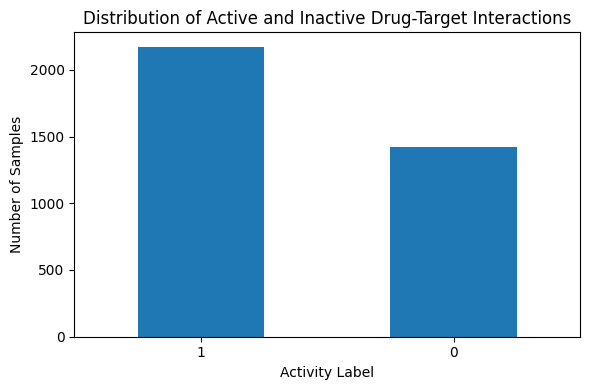

In [21]:
# 9.2 Visualise Class Distribution


plt.figure(
    figsize=(6,4)
)


class_distribution.plot(
    kind="bar"
)


plt.title(
    "Distribution of Active and Inactive Drug-Target Interactions"
)


plt.xlabel(
    "Activity Label"
)


plt.ylabel(
    "Number of Samples"
)


plt.xticks(
    rotation=0
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "integrated_class_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [17]:
# 10. Feature Scaling


scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X
)


print(
    "Feature scaling completed successfully."
)


print(
    "Scaled feature shape:",
    X_scaled.shape
)

Feature scaling completed successfully.
Scaled feature shape: (3590, 320)


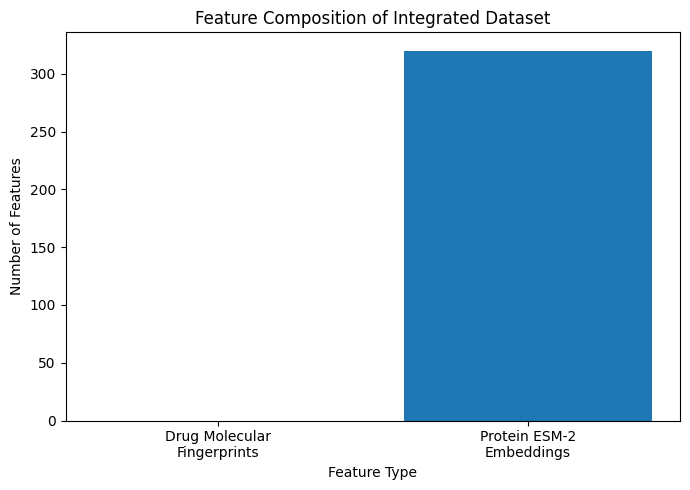

In [22]:
# 10.1 Feature Composition Visualisation


feature_types = [
    "Drug Molecular\nFingerprints",
    "Protein ESM-2\nEmbeddings"
]


feature_counts = [
    len(fingerprint_columns),
    len(protein_feature_columns)
]


plt.figure(
    figsize=(7,5)
)


plt.bar(
    feature_types,
    feature_counts
)


plt.title(
    "Feature Composition of Integrated Dataset"
)


plt.xlabel(
    "Feature Type"
)


plt.ylabel(
    "Number of Features"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "integrated_feature_dimensions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [18]:
# 11. Save Integrated Dataset


integrated_features_file = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_features.npy"
)


integrated_labels_file = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_labels.npy"
)


np.save(
    integrated_features_file,
    X_scaled
)


np.save(
    integrated_labels_file,
    y.values
)


print(
    "Integrated datasets saved successfully."
)

Integrated datasets saved successfully.


In [19]:
# 11.1 Save Integrated Metadata


metadata_output_file = os.path.join(
    PROCESSED_DATA_PATH,
    "integrated_metadata.csv"
)


integrated_df.to_csv(
    metadata_output_file,
    index=False
)


print(
    "Integrated metadata saved successfully."
)

Integrated metadata saved successfully.


In [20]:
# 12. Download Generated Files


from google.colab import files


files.download(
    integrated_features_file
)


files.download(
    integrated_labels_file
)


files.download(
    metadata_output_file
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Findings

This notebook integrated drug molecular features and protein sequence embeddings
to create a unified dataset for downstream artificial intelligence modelling.

The molecular fingerprint features generated from drug SMILES structures were
combined with protein representations generated using the pretrained ESM-2
transformer model.

The integrated dataset combines chemical information from drugs and biological
sequence information from depression-associated protein targets, creating a
comprehensive feature representation for machine learning approaches.

Dataset validation was performed by checking feature dimensions, missing values,
duplicate samples, and activity label distribution. Visualisations were created
to examine the class distribution and the contribution of drug and protein
features within the integrated feature space.

Feature scaling was applied to prepare the dataset for advanced machine learning
models. The final integrated feature matrix, labels, and metadata were saved for
use in subsequent stages, including Graph Neural Network development and
novel drug-target interaction prediction.